# 03 — Data Cleaning
## Climate Change: Earth Surface Temperature Analysis

**Người thực hiện:** Lê Bá Hiền — Data Cleaning  
**Nguồn vào:** 5 analytical view PostgreSQL do `02_postgresql_pipeline.ipynb` bàn giao.  
**Nguồn ra chính:** 5 bảng `clean_*_temperature` trong PostgreSQL; đồng thời xuất bản sao CSV tái tạo được vào `data/processed/`.

### Mục tiêu

Notebook biến dữ liệu đã tích hợp trong PostgreSQL thành dữ liệu sạch, nhất quán và sẵn sàng cho EDA. Quy trình xử lý:

```text
PostgreSQL views
        ↓
pd.read_sql_query()
        ↓
Quality Assessment — Before Cleaning
        ↓
Missing · Duplicate · Invalid · Outlier · Logic Validation
        ↓
Create clean_* tables in PostgreSQL
        ↓
Quality Assessment — After Cleaning
        ↓
CSV export + Final audit
        ↓
Notebook 04 — EDA & Visualization
```

Notebook không đọc lại CSV gốc. Mọi thống kê và kết quả làm sạch đều xuất phát từ data contract mới nhất của notebook 01–02.

## 1. Chuẩn bị môi trường và kết nối PostgreSQL

Thông tin kết nối được đọc từ `.env`; mật khẩu không xuất hiện trong source code hoặc output. Kết nối được kiểm tra ở chế độ chỉ đọc trước khi tiến hành đánh giá dữ liệu.

In [24]:
import os
import re
import warnings
from contextlib import closing
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
from dotenv import load_dotenv
from IPython.display import display

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
warnings.filterwarnings(
    'ignore',
    message='pandas only supports SQLAlchemy connectable',
    category=UserWarning,
)

PHYSICAL_MIN_TEMP_C = -90.0
PHYSICAL_MAX_TEMP_C = 57.0

print('Pandas:', pd.__version__)
print('psycopg2:', psycopg2.__version__)

Pandas: 3.0.3
psycopg2: 2.9.12 (dt dec pq3 ext lo64)


In [25]:
def find_project_root(start: Path) -> Path:
    """Tìm thư mục gốc chứa data/ và notebooks/."""
    for candidate in (start, *start.parents):
        if (candidate / 'data').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Không tìm thấy project root chứa data/ và notebooks/.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

env_path = PROJECT_ROOT / '.env'
if not env_path.is_file():
    raise FileNotFoundError(
        f'Không tìm thấy {env_path}. Hãy sao chép .env.example thành .env '
        'và điền thông tin climate_db.'
    )

load_dotenv(env_path, override=False)
required_env = ('DB_HOST', 'DB_PORT', 'DB_NAME', 'DB_USER', 'DB_PASSWORD')
missing_env = [name for name in required_env if not os.getenv(name)]
if missing_env:
    raise EnvironmentError('.env thiếu biến: ' + ', '.join(missing_env))

DB_CONFIG = {
    'host': os.environ['DB_HOST'],
    'port': int(os.environ['DB_PORT']),
    'dbname': os.environ['DB_NAME'],
    'user': os.environ['DB_USER'],
    'password': os.environ['DB_PASSWORD'],
    'connect_timeout': 10,
}

with closing(psycopg2.connect(**DB_CONFIG)) as connection:
    connection.set_session(readonly=True, autocommit=True)
    with connection.cursor() as cursor:
        cursor.execute(
            'SELECT current_database(), current_user, current_schema(), version();'
        )
        database_name, database_user, active_schema, postgresql_version = cursor.fetchone()

print('Project root :', PROJECT_ROOT)
print('Database     :', database_name)
print('User         :', database_user)
print('Schema       :', active_schema)
print('PostgreSQL   :', postgresql_version.split(',')[0])

Project root : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis
Database     : climate_db
User         : postgres
Schema       : public
PostgreSQL   : PostgreSQL 18.3 on x86_64-windows


## 2. Đọc dữ liệu từ PostgreSQL

Notebook sử dụng `pd.read_sql_query()` để đọc metadata, thống kê, mẫu dữ liệu và kết quả audit. Với bảng City hơn 5 triệu dòng, các phép làm sạch được thực thi trực tiếp trong PostgreSQL để tránh sao chép toàn bộ dữ liệu nhiều lần vào RAM.

Data contract dưới đây kế thừa trực tiếp notebook 02. Nếu số dòng hoặc view không khớp, notebook dừng ngay để tránh tạo kết quả từ database cũ.

In [26]:
DATASETS = {
    'global': {
        'source_table': 'vw_global_temperature',
        'clean_table': 'clean_global_temperature',
        'id_column': 'global_temperature_id',
        'date_column': 'observation_date',
        'core_temperature': 'land_average_temperature',
        'temperature_columns': [
            'land_average_temperature', 'land_max_temperature',
            'land_min_temperature', 'land_and_ocean_average_temperature',
        ],
        'uncertainty_columns': [
            'land_average_temperature_uncertainty',
            'land_max_temperature_uncertainty',
            'land_min_temperature_uncertainty',
            'land_and_ocean_average_temperature_uncertainty',
        ],
        'entity_columns': [],
        'coordinate_columns': [],
        'key_columns': ['observation_date'],
        'expected_source_rows': 3_192,
        'expected_clean_rows': 3_180,
    },
    'country': {
        'source_table': 'vw_country_temperature',
        'clean_table': 'clean_country_temperature',
        'id_column': 'country_temperature_id',
        'date_column': 'observation_date',
        'core_temperature': 'average_temperature',
        'temperature_columns': ['average_temperature'],
        'uncertainty_columns': ['average_temperature_uncertainty'],
        'entity_columns': ['country_name'],
        'coordinate_columns': [],
        'key_columns': ['observation_date', 'country_name'],
        'expected_source_rows': 577_462,
        'expected_clean_rows': 544_811,
    },
    'state': {
        'source_table': 'vw_state_temperature',
        'clean_table': 'clean_state_temperature',
        'id_column': 'state_temperature_id',
        'date_column': 'observation_date',
        'core_temperature': 'average_temperature',
        'temperature_columns': ['average_temperature'],
        'uncertainty_columns': ['average_temperature_uncertainty'],
        'entity_columns': ['state_name', 'country_name'],
        'coordinate_columns': [],
        'key_columns': ['observation_date', 'state_name', 'country_name'],
        'expected_source_rows': 645_675,
        'expected_clean_rows': 620_027,
    },
    'city': {
        'source_table': 'vw_city_temperature',
        'clean_table': 'clean_city_temperature',
        'id_column': 'city_temperature_id',
        'date_column': 'observation_date',
        'core_temperature': 'average_temperature',
        'temperature_columns': ['average_temperature'],
        'uncertainty_columns': ['average_temperature_uncertainty'],
        'entity_columns': ['city_name', 'country_name'],
        'coordinate_columns': ['latitude', 'longitude'],
        'key_columns': [
            'observation_date', 'city_name', 'country_name', 'latitude', 'longitude'
        ],
        'expected_source_rows': 5_010_113,
        'expected_clean_rows': 4_967_012,
    },
    'major_city': {
        'source_table': 'vw_major_city_temperature',
        'clean_table': 'clean_major_city_temperature',
        'id_column': 'major_city_temperature_id',
        'date_column': 'observation_date',
        'core_temperature': 'average_temperature',
        'temperature_columns': ['average_temperature'],
        'uncertainty_columns': ['average_temperature_uncertainty'],
        'entity_columns': ['city_name', 'country_name'],
        'coordinate_columns': ['latitude', 'longitude'],
        'key_columns': [
            'observation_date', 'city_name', 'country_name', 'latitude', 'longitude'
        ],
        'expected_source_rows': 239_177,
        'expected_clean_rows': 228_175,
    },
}


def validate_identifier(name: str) -> str:
    """Chỉ chấp nhận identifier SQL đơn giản do notebook kiểm soát."""
    if not re.fullmatch(r'[a-z_][a-z0-9_]*', name):
        raise ValueError(f'Identifier SQL không hợp lệ: {name}')
    return name


for config in DATASETS.values():
    for value in (
        config['source_table'],
        config['clean_table'],
        config['id_column'],
        config['date_column'],
        config['core_temperature'],
        *config['key_columns'],
    ):
        validate_identifier(value)

print(f'Đã cấu hình {len(DATASETS)} dataset PostgreSQL.')

Đã cấu hình 5 dataset PostgreSQL.


In [27]:
def read_sql(query: str, params=None) -> pd.DataFrame:
    """Đọc kết quả truy vấn PostgreSQL thành DataFrame."""
    with closing(psycopg2.connect(**DB_CONFIG)) as connection:
        connection.set_session(readonly=True, autocommit=True)
        return pd.read_sql_query(query, connection, params=params)


def execute_sql(statement: str) -> None:
    """Thực thi một transaction SQL; rollback toàn bộ nếu có lỗi."""
    with closing(psycopg2.connect(**DB_CONFIG)) as connection:
        try:
            with connection.cursor() as cursor:
                cursor.execute(statement)
            connection.commit()
        except Exception:
            connection.rollback()
            raise


def scalar_sql(query: str, params=None):
    """Trả về giá trị đầu tiên của truy vấn một dòng/một cột."""
    return read_sql(query, params).iat[0, 0]

In [28]:
contract_rows = []
samples = {}

for dataset_name, config in DATASETS.items():
    table = config['source_table']
    overview = read_sql(
        f'''
        SELECT
            COUNT(*)::BIGINT AS row_count,
            MIN({config["date_column"]}) AS min_date,
            MAX({config["date_column"]}) AS max_date
        FROM public.{table};
        '''
    ).iloc[0]

    column_count = scalar_sql(
        '''
        SELECT COUNT(*)::BIGINT
        FROM information_schema.columns
        WHERE table_schema = 'public' AND table_name = %s;
        ''',
        (table,),
    )
    actual_rows = int(overview['row_count'])
    contract_rows.append({
        'dataset': dataset_name,
        'source_view': table,
        'rows': actual_rows,
        'columns': int(column_count),
        'min_date': overview['min_date'],
        'max_date': overview['max_date'],
        'expected_rows': config['expected_source_rows'],
        'status': 'PASS' if actual_rows == config['expected_source_rows'] else 'FAIL',
    })
    samples[dataset_name] = read_sql(
        f'SELECT * FROM public.{table} '
        f'ORDER BY {config["id_column"]} LIMIT 3;'
    )

SOURCE_CONTRACT_DF = pd.DataFrame(contract_rows)
display(SOURCE_CONTRACT_DF)

failed_contracts = SOURCE_CONTRACT_DF.loc[
    SOURCE_CONTRACT_DF['status'].ne('PASS'), 'dataset'
].tolist()
if failed_contracts:
    raise RuntimeError(
        'Data contract không khớp notebook 02: ' + ', '.join(failed_contracts)
    )

print('SOURCE DATA CONTRACT: PASS')
print('\nMẫu dữ liệu Country:')
display(samples['country'])

,dataset,source_view,rows,columns,min_date,max_date,expected_rows,status
0,global,vw_global_temperature,3192,16,1750-01-01,2015-12-01,3192,PASS
1,country,vw_country_temperature,577462,12,1743-11-01,2013-09-01,577462,PASS
2,state,vw_state_temperature,645675,14,1743-11-01,2013-09-01,645675,PASS
3,city,vw_city_temperature,5010113,17,1863-01-01,2013-09-01,5010113,PASS
4,major_city,vw_major_city_temperature,239177,17,1743-11-01,2013-09-01,239177,PASS


SOURCE DATA CONTRACT: PASS

Mẫu dữ liệu Country:


,country_temperature_id,source_staging_id,date_id,observation_date,year,month,quarter,decade,country_id,country_name,average_temperature,average_temperature_uncertainty
0,1,1,1,1743-11-01,1743,11,4,1740,3,Åland,4.3840,2.2940
1,2,2,2,1743-12-01,1743,12,4,1740,3,Åland,NaN,NaN
2,3,3,3,1744-01-01,1744,1,1,1740,3,Åland,NaN,NaN


### Nhận xét kết quả đọc dữ liệu

Kết quả hợp lệ phải xác nhận đủ 5 view. Riêng City có **5.010.113 dòng**, thuộc 80 quốc gia và giai đoạn 1863–2013 theo phạm vi đã cắt tại notebook 02. Đây là số liệu đầu vào chính thức của notebook 03; không sử dụng lại số dòng 8.599.212 của CSV City thô.

## 3. Đánh giá chất lượng dữ liệu trước làm sạch

Phần này kiểm tra đầy đủ shape, kiểu dữ liệu SQL, dung lượng payload, missing, duplicate, invalid values, outlier và các điều kiện logic. Các phép đếm chạy trên toàn bộ dữ liệu PostgreSQL, không suy ra từ sample.

In [29]:
def build_conditions(config: dict) -> dict:
    """Sinh các điều kiện audit phù hợp schema từng dataset."""
    date_col = config['date_column']
    temp_col = config['core_temperature']
    missing_core = [f'{date_col} IS NULL', f'{temp_col} IS NULL']
    missing_core += [
        f"({col} IS NULL OR BTRIM({col}) = '')"
        for col in config['entity_columns']
    ]
    missing_core += [f'{col} IS NULL' for col in config['coordinate_columns']]

    invalid = [
        f'({col} IS NOT NULL AND '
        f'{col} NOT BETWEEN {PHYSICAL_MIN_TEMP_C} AND {PHYSICAL_MAX_TEMP_C})'
        for col in config['temperature_columns']
    ]
    invalid += [
        f'({col} IS NOT NULL AND {col} < 0)'
        for col in config['uncertainty_columns']
    ]
    if config['coordinate_columns']:
        invalid += [
            '(latitude IS NOT NULL AND latitude NOT BETWEEN -90 AND 90)',
            '(longitude IS NOT NULL AND longitude NOT BETWEEN -180 AND 180)',
        ]

    logic = [
        f'({date_col} IS NOT NULL AND EXTRACT(DAY FROM {date_col}) <> 1)'
    ]
    if not config['entity_columns']:
        logic += [
            '(land_min_temperature IS NOT NULL '
            'AND land_average_temperature IS NOT NULL '
            'AND land_min_temperature > land_average_temperature)',
            '(land_max_temperature IS NOT NULL '
            'AND land_average_temperature IS NOT NULL '
            'AND land_average_temperature > land_max_temperature)',
        ]

    return {
        'missing_core': ' OR '.join(missing_core),
        'invalid': ' OR '.join(invalid),
        'logic': ' OR '.join(logic),
    }


def table_columns(table: str) -> list[str]:
    """Lấy toàn bộ cột thật của table/view theo đúng ordinal position."""
    return read_sql(
        '''
        SELECT column_name
        FROM information_schema.columns
        WHERE table_schema = 'public' AND table_name = %s
        ORDER BY ordinal_position;
        ''',
        (table,),
    )['column_name'].tolist()


def profile_dataset(dataset_name: str, table: str) -> dict:
    """Tính các chỉ số chất lượng chính cho toàn bộ một table/view."""
    config = DATASETS[dataset_name]
    conditions = build_conditions(config)
    all_columns = table_columns(table)
    missing_sum = ' + '.join(
        f'COUNT(*) FILTER (WHERE {column} IS NULL)'
        for column in all_columns
    )
    summary = read_sql(
        f'''
        SELECT
            COUNT(*)::BIGINT AS rows,
            COALESCE(SUM(pg_column_size(t)), 0)::BIGINT AS payload_bytes,
            ({missing_sum})::BIGINT AS missing_cells,
            COUNT(*) FILTER (
                WHERE {conditions["missing_core"]}
            )::BIGINT AS core_missing_rows,
            COUNT(*) FILTER (
                WHERE {conditions["invalid"]}
            )::BIGINT AS invalid_rows,
            COUNT(*) FILTER (
                WHERE {conditions["logic"]}
            )::BIGINT AS logic_invalid_rows
        FROM public.{table} AS t;
        '''
    ).iloc[0]

    key_sql = ', '.join(config['key_columns'])
    duplicate_rows = scalar_sql(
        f'''
        SELECT COALESCE(SUM(group_count - 1), 0)::BIGINT
        FROM (
            SELECT COUNT(*)::BIGINT AS group_count
            FROM public.{table}
            GROUP BY {key_sql}
            HAVING COUNT(*) > 1
        ) AS duplicated_keys;
        '''
    )

    temp_col = config['core_temperature']
    bounds = read_sql(
        f'''
        SELECT
            PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY {temp_col}) AS q1,
            PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY {temp_col}) AS q3,
            AVG({temp_col}) AS mean_value,
            STDDEV_SAMP({temp_col}) AS std_value
        FROM public.{table}
        WHERE {temp_col} IS NOT NULL;
        '''
    ).iloc[0]
    q1, q3 = float(bounds['q1']), float(bounds['q3'])
    iqr = q3 - q1
    lower_iqr, upper_iqr = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mean_value, std_value = float(bounds['mean_value']), float(bounds['std_value'])
    lower_z, upper_z = mean_value - 3 * std_value, mean_value + 3 * std_value
    outliers = read_sql(
        f'''
        SELECT
            COUNT(*) FILTER (
                WHERE {temp_col} < %s OR {temp_col} > %s
            )::BIGINT AS iqr_outliers,
            COUNT(*) FILTER (
                WHERE {temp_col} < %s OR {temp_col} > %s
            )::BIGINT AS zscore_outliers
        FROM public.{table}
        WHERE {temp_col} IS NOT NULL;
        ''',
        (lower_iqr, upper_iqr, lower_z, upper_z),
    ).iloc[0]

    return {
        'dataset': dataset_name,
        'table': table,
        'rows': int(summary['rows']),
        'columns': len(all_columns),
        'payload_mb': int(summary['payload_bytes']) / (1024 ** 2),
        'missing_cells': int(summary['missing_cells']),
        'core_missing_rows': int(summary['core_missing_rows']),
        'duplicate_rows': int(duplicate_rows),
        'invalid_rows': int(summary['invalid_rows']),
        'logic_invalid_rows': int(summary['logic_invalid_rows']),
        'iqr_outliers': int(outliers['iqr_outliers']),
        'zscore_outliers': int(outliers['zscore_outliers']),
        'iqr_lower_c': lower_iqr,
        'iqr_upper_c': upper_iqr,
    }


def missing_detail(dataset_name: str, table: str) -> pd.DataFrame:
    """Trả bảng missing count và percentage theo từng cột cần audit."""
    config = DATASETS[dataset_name]
    columns = table_columns(table)
    expressions = ', '.join(
        f'COUNT(*) FILTER (WHERE {column} IS NULL)::BIGINT AS {column}'
        for column in columns
    )
    counts = read_sql(
        f'SELECT COUNT(*)::BIGINT AS total_rows, {expressions} '
        f'FROM public.{table};'
    ).iloc[0]
    total_rows = int(counts['total_rows'])
    return pd.DataFrame([
        {
            'dataset': dataset_name,
            'column': column,
            'missing_count': int(counts[column]),
            'missing_percent': (
                int(counts[column]) / total_rows * 100 if total_rows else 0.0
            ),
        }
        for column in columns
    ])

In [30]:
before_profiles = []
before_missing_parts = []

for dataset_name, config in DATASETS.items():
    print(f'Đang audit trước làm sạch: {dataset_name} ...')
    before_profiles.append(
        profile_dataset(dataset_name, config['source_table'])
    )
    before_missing_parts.append(
        missing_detail(dataset_name, config['source_table'])
    )

BEFORE_PROFILE_DF = pd.DataFrame(before_profiles)
BEFORE_MISSING_DF = pd.concat(before_missing_parts, ignore_index=True)

display(BEFORE_PROFILE_DF)
display(
    BEFORE_MISSING_DF.loc[BEFORE_MISSING_DF['missing_count'].gt(0)]
    .sort_values(['dataset', 'missing_percent'], ascending=[True, False])
)

Đang audit trước làm sạch: global ...
Đang audit trước làm sạch: country ...
Đang audit trước làm sạch: state ...
Đang audit trước làm sạch: city ...
Đang audit trước làm sạch: major_city ...


,dataset,table,rows,columns,payload_mb,missing_cells,core_missing_rows,duplicate_rows,invalid_rows,logic_invalid_rows,iqr_outliers,zscore_outliers,iqr_lower_c,iqr_upper_c
0,global,vw_global_temperature,3192,16,0.3436,7224,12,0,0,0,0,0,-8.0424,24.9026
1,country,vw_country_temperature,577462,12,55.5333,64563,32651,0,0,0,6438,5439,-13.6585,49.4975
2,state,vw_state_temperature,645675,14,73.2161,51296,25648,0,0,0,2444,1985,-31.5810,50.7870
3,city,vw_city_temperature,5010113,17,680.7743,86202,43101,0,0,0,75490,49133,-11.5800,46.9560
4,major_city,vw_major_city_temperature,239177,17,32.1288,22004,11002,0,0,0,4395,1621,-7.1020,45.7300


,dataset,column,missing_count,missing_percent
57,city,average_temperature,43101,0.8603
58,city,average_temperature_uncertainty,43101,0.8603
26,country,average_temperature,32651,5.6542
27,country,average_temperature_uncertainty,31912,5.5263
10,global,land_max_temperature,1200,37.5940
11,global,land_max_temperature_uncertainty,1200,37.5940
12,global,land_min_temperature,1200,37.5940
13,global,land_min_temperature_uncertainty,1200,37.5940
14,global,land_and_ocean_average_temperature,1200,37.5940
15,global,land_and_ocean_average_temperature_uncertainty,1200,37.5940


In [31]:
SOURCE_TYPES_DF = read_sql(
    '''
    SELECT table_name, ordinal_position, column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'public'
      AND table_name = ANY(%s)
    ORDER BY table_name, ordinal_position;
    ''',
    ([config['source_table'] for config in DATASETS.values()],),
)
display(SOURCE_TYPES_DF)

type_summary = (
    SOURCE_TYPES_DF.groupby(['table_name', 'data_type'], observed=True)
    .size()
    .rename('column_count')
    .reset_index()
)
display(type_summary)

,table_name,ordinal_position,column_name,data_type
0,vw_city_temperature,1,city_temperature_id,bigint
1,vw_city_temperature,2,source_staging_id,bigint
2,vw_city_temperature,3,date_id,bigint
3,vw_city_temperature,4,observation_date,date
4,vw_city_temperature,5,year,smallint
...,...,...,...,...
71,vw_state_temperature,10,state_name,text
72,vw_state_temperature,11,country_id,bigint
73,vw_state_temperature,12,country_name,text
74,vw_state_temperature,13,average_temperature,double precision


,table_name,data_type,column_count
0,vw_city_temperature,bigint,5
1,vw_city_temperature,boolean,1
2,vw_city_temperature,date,1
3,vw_city_temperature,double precision,4
4,vw_city_temperature,smallint,4
5,vw_city_temperature,text,2
6,vw_country_temperature,bigint,4
7,vw_country_temperature,date,1
8,vw_country_temperature,double precision,2
9,vw_country_temperature,smallint,4


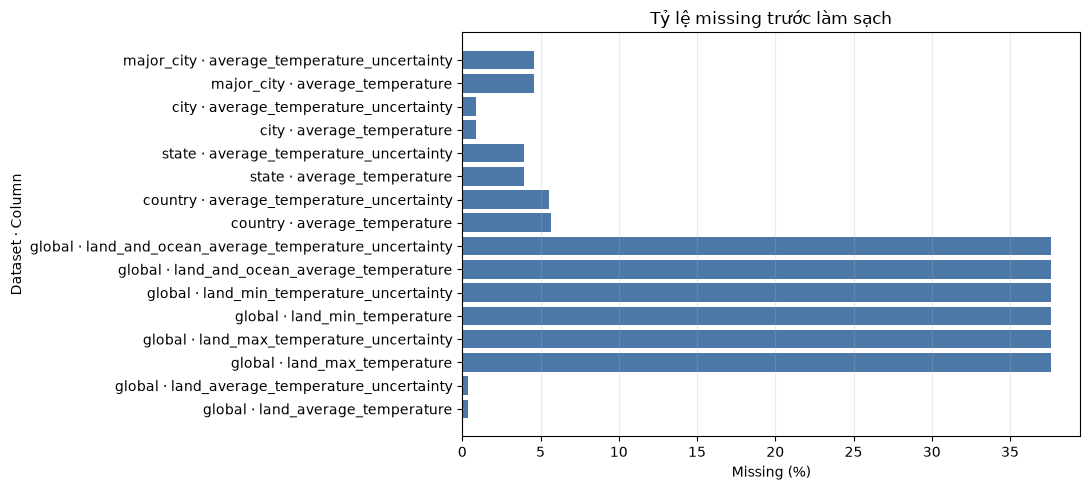

In [32]:
missing_for_plot = BEFORE_MISSING_DF.loc[
    BEFORE_MISSING_DF['missing_count'].gt(0)
].copy()
missing_for_plot['label'] = (
    missing_for_plot['dataset'] + ' · ' + missing_for_plot['column']
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(
    missing_for_plot['label'],
    missing_for_plot['missing_percent'],
    color='#4C78A8',
)
ax.set_title('Tỷ lệ missing trước làm sạch')
ax.set_xlabel('Missing (%)')
ax.set_ylabel('Dataset · Column')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

### Nhận xét trước làm sạch

Các kiểm tra toàn bộ PostgreSQL cho thấy:

- Không có duplicate theo grain nghiệp vụ; vì vậy không cần xóa bản ghi trùng trong phiên bản dữ liệu hiện tại.
- Không có nhiệt độ vượt miền vật lý, uncertainty âm, tọa độ sai phạm vi hoặc ngày không nằm ở đầu tháng.
- Vấn đề cần xử lý thực tế là missing của nhiệt độ cốt lõi: Global 12, Country 32.651, State 25.648, City 43.101 và Major City 11.002 dòng.
- Country có một số dòng còn nhiệt độ nhưng thiếu uncertainty; các dòng này được điền median theo quốc gia. Với các dataset còn lại, uncertainty thiếu chủ yếu xuất hiện cùng dòng thiếu nhiệt độ và biến mất sau khi loại dòng thiếu target.
- Outlier IQR/Z-score vẫn được ghi nhận, nhưng không đồng nghĩa dữ liệu sai. Các giá trị còn trong miền vật lý được giữ lại để tránh làm mất cực trị khí hậu thật.

Cột `payload_mb` là dung lượng payload PostgreSQL của toàn bộ các dòng, dùng làm chỉ báo quy mô dữ liệu. Notebook không giữ đồng thời toàn bộ 5 DataFrame trong RAM.

## 4. Quy tắc làm sạch

| Nhóm vấn đề | Quy tắc | Lý do |
|---|---|---|
| Ngày | Chỉ giữ ngày hợp lệ và ngày đầu tháng | Grain của dữ liệu là một quan sát mỗi tháng |
| Thiếu nhiệt độ cốt lõi | Xóa dòng | Không thể suy luận đáng tin cậy target khí hậu lịch sử |
| Thiếu uncertainty | Median theo entity, fallback median toàn dataset | Giữ quan sát nhiệt độ hợp lệ và hạn chế ảnh hưởng cực trị |
| Thiếu tên địa điểm/tọa độ | Xóa dòng | Không thể gắn quan sát vào đúng không gian |
| Duplicate | Kiểm tra theo business key; unique constraint ngăn tái xuất hiện | Dữ liệu hiện tại không có duplicate |
| Invalid temperature | Loại ngoài [-90°C, 57°C] | Ngoài miền vật lý chấp nhận của dự án |
| Invalid uncertainty | Loại uncertainty âm | Độ bất định không thể âm |
| Outlier IQR/Z-score | Giữ nếu vẫn hợp lệ vật lý | Có thể là cực trị khí hậu thật |
| Text/category | Kế thừa chuẩn hóa từ dimension PostgreSQL | Tránh làm sai tên riêng và khóa quan hệ |
| Global secondary measures | Giữ NULL lịch sử | Các phép đo bắt đầu muộn; missing có hệ thống |

Các bảng sạch là bảng dẫn xuất. Cell tạo bảng chỉ xóa và tạo lại đúng 5 bảng có tiền tố `clean_`; không sửa view nguồn, fact, dimension hoặc CSV raw.

## 5. Tạo các bảng sạch trong PostgreSQL

Toàn bộ thao tác chạy trong một transaction. Nếu bất kỳ câu lệnh nào lỗi, PostgreSQL rollback để không để lại pipeline dở dang.

In [33]:
CLEANING_SQL = f'''
DROP TABLE IF EXISTS
    public.clean_global_temperature,
    public.clean_country_temperature,
    public.clean_state_temperature,
    public.clean_city_temperature,
    public.clean_major_city_temperature
CASCADE;

CREATE TABLE public.clean_global_temperature AS
SELECT *
FROM public.vw_global_temperature
WHERE observation_date IS NOT NULL
  AND EXTRACT(DAY FROM observation_date) = 1
  AND land_average_temperature BETWEEN {PHYSICAL_MIN_TEMP_C} AND {PHYSICAL_MAX_TEMP_C}
  AND (
      land_max_temperature IS NULL
      OR land_max_temperature BETWEEN {PHYSICAL_MIN_TEMP_C} AND {PHYSICAL_MAX_TEMP_C}
  )
  AND (
      land_min_temperature IS NULL
      OR land_min_temperature BETWEEN {PHYSICAL_MIN_TEMP_C} AND {PHYSICAL_MAX_TEMP_C}
  )
  AND (
      land_and_ocean_average_temperature IS NULL
      OR land_and_ocean_average_temperature
         BETWEEN {PHYSICAL_MIN_TEMP_C} AND {PHYSICAL_MAX_TEMP_C}
  )
  AND (
      land_average_temperature_uncertainty IS NULL
      OR land_average_temperature_uncertainty >= 0
  )
  AND (
      land_max_temperature_uncertainty IS NULL
      OR land_max_temperature_uncertainty >= 0
  )
  AND (
      land_min_temperature_uncertainty IS NULL
      OR land_min_temperature_uncertainty >= 0
  )
  AND (
      land_and_ocean_average_temperature_uncertainty IS NULL
      OR land_and_ocean_average_temperature_uncertainty >= 0
  );

CREATE TABLE public.clean_country_temperature AS
SELECT *
FROM public.vw_country_temperature
WHERE observation_date IS NOT NULL
  AND EXTRACT(DAY FROM observation_date) = 1
  AND country_name IS NOT NULL
  AND BTRIM(country_name) <> ''
  AND average_temperature BETWEEN {PHYSICAL_MIN_TEMP_C} AND {PHYSICAL_MAX_TEMP_C}
  AND (
      average_temperature_uncertainty IS NULL
      OR average_temperature_uncertainty >= 0
  );

CREATE TABLE public.clean_state_temperature AS
SELECT *
FROM public.vw_state_temperature
WHERE observation_date IS NOT NULL
  AND EXTRACT(DAY FROM observation_date) = 1
  AND state_name IS NOT NULL
  AND BTRIM(state_name) <> ''
  AND country_name IS NOT NULL
  AND BTRIM(country_name) <> ''
  AND average_temperature BETWEEN {PHYSICAL_MIN_TEMP_C} AND {PHYSICAL_MAX_TEMP_C}
  AND (
      average_temperature_uncertainty IS NULL
      OR average_temperature_uncertainty >= 0
  );

CREATE TABLE public.clean_city_temperature AS
SELECT *
FROM public.vw_city_temperature
WHERE observation_date IS NOT NULL
  AND EXTRACT(DAY FROM observation_date) = 1
  AND city_name IS NOT NULL
  AND BTRIM(city_name) <> ''
  AND country_name IS NOT NULL
  AND BTRIM(country_name) <> ''
  AND latitude BETWEEN -90 AND 90
  AND longitude BETWEEN -180 AND 180
  AND average_temperature BETWEEN {PHYSICAL_MIN_TEMP_C} AND {PHYSICAL_MAX_TEMP_C}
  AND (
      average_temperature_uncertainty IS NULL
      OR average_temperature_uncertainty >= 0
  );

CREATE TABLE public.clean_major_city_temperature AS
SELECT *
FROM public.vw_major_city_temperature
WHERE observation_date IS NOT NULL
  AND EXTRACT(DAY FROM observation_date) = 1
  AND city_name IS NOT NULL
  AND BTRIM(city_name) <> ''
  AND country_name IS NOT NULL
  AND BTRIM(country_name) <> ''
  AND latitude BETWEEN -90 AND 90
  AND longitude BETWEEN -180 AND 180
  AND average_temperature BETWEEN {PHYSICAL_MIN_TEMP_C} AND {PHYSICAL_MAX_TEMP_C}
  AND (
      average_temperature_uncertainty IS NULL
      OR average_temperature_uncertainty >= 0
  );

-- Điền uncertainty còn thiếu bằng median theo entity.
WITH medians AS (
    SELECT
        country_id,
        PERCENTILE_CONT(0.5) WITHIN GROUP (
            ORDER BY average_temperature_uncertainty
        ) AS median_uncertainty
    FROM public.clean_country_temperature
    WHERE average_temperature_uncertainty IS NOT NULL
    GROUP BY country_id
)
UPDATE public.clean_country_temperature AS target
SET average_temperature_uncertainty = medians.median_uncertainty
FROM medians
WHERE target.country_id = medians.country_id
  AND target.average_temperature_uncertainty IS NULL;

WITH medians AS (
    SELECT
        state_id,
        PERCENTILE_CONT(0.5) WITHIN GROUP (
            ORDER BY average_temperature_uncertainty
        ) AS median_uncertainty
    FROM public.clean_state_temperature
    WHERE average_temperature_uncertainty IS NOT NULL
    GROUP BY state_id
)
UPDATE public.clean_state_temperature AS target
SET average_temperature_uncertainty = medians.median_uncertainty
FROM medians
WHERE target.state_id = medians.state_id
  AND target.average_temperature_uncertainty IS NULL;

WITH medians AS (
    SELECT
        city_id,
        PERCENTILE_CONT(0.5) WITHIN GROUP (
            ORDER BY average_temperature_uncertainty
        ) AS median_uncertainty
    FROM public.clean_city_temperature
    WHERE average_temperature_uncertainty IS NOT NULL
    GROUP BY city_id
)
UPDATE public.clean_city_temperature AS target
SET average_temperature_uncertainty = medians.median_uncertainty
FROM medians
WHERE target.city_id = medians.city_id
  AND target.average_temperature_uncertainty IS NULL;

WITH medians AS (
    SELECT
        city_id,
        PERCENTILE_CONT(0.5) WITHIN GROUP (
            ORDER BY average_temperature_uncertainty
        ) AS median_uncertainty
    FROM public.clean_major_city_temperature
    WHERE average_temperature_uncertainty IS NOT NULL
    GROUP BY city_id
)
UPDATE public.clean_major_city_temperature AS target
SET average_temperature_uncertainty = medians.median_uncertainty
FROM medians
WHERE target.city_id = medians.city_id
  AND target.average_temperature_uncertainty IS NULL;

-- Fallback median toàn dataset nếu một entity không có median riêng.
UPDATE public.clean_country_temperature
SET average_temperature_uncertainty = (
    SELECT PERCENTILE_CONT(0.5) WITHIN GROUP (
        ORDER BY average_temperature_uncertainty
    )
    FROM public.clean_country_temperature
    WHERE average_temperature_uncertainty IS NOT NULL
)
WHERE average_temperature_uncertainty IS NULL;

-- Bảo toàn grain và khóa định danh sau cleaning.
ALTER TABLE public.clean_global_temperature
    ADD PRIMARY KEY (global_temperature_id),
    ADD CONSTRAINT uq_clean_global_date UNIQUE (observation_date);

ALTER TABLE public.clean_country_temperature
    ADD PRIMARY KEY (country_temperature_id),
    ADD CONSTRAINT uq_clean_country_grain UNIQUE (observation_date, country_name);

ALTER TABLE public.clean_state_temperature
    ADD PRIMARY KEY (state_temperature_id),
    ADD CONSTRAINT uq_clean_state_grain
        UNIQUE (observation_date, state_name, country_name);

ALTER TABLE public.clean_city_temperature
    ADD PRIMARY KEY (city_temperature_id),
    ADD CONSTRAINT uq_clean_city_grain
        UNIQUE (observation_date, city_name, country_name, latitude, longitude);

ALTER TABLE public.clean_major_city_temperature
    ADD PRIMARY KEY (major_city_temperature_id),
    ADD CONSTRAINT uq_clean_major_city_grain
        UNIQUE (observation_date, city_name, country_name, latitude, longitude);

CREATE INDEX idx_clean_country_date_country
    ON public.clean_country_temperature (observation_date, country_id);
CREATE INDEX idx_clean_state_date_state
    ON public.clean_state_temperature (observation_date, state_id);
CREATE INDEX idx_clean_city_date_city
    ON public.clean_city_temperature (observation_date, city_id);
CREATE INDEX idx_clean_major_city_date_city
    ON public.clean_major_city_temperature (observation_date, city_id);

COMMENT ON TABLE public.clean_global_temperature IS
    'Clean global monthly temperature data produced by notebook 03';
COMMENT ON TABLE public.clean_country_temperature IS
    'Clean country monthly temperature data produced by notebook 03';
COMMENT ON TABLE public.clean_state_temperature IS
    'Clean state monthly temperature data produced by notebook 03';
COMMENT ON TABLE public.clean_city_temperature IS
    'Clean city monthly temperature data produced by notebook 03';
COMMENT ON TABLE public.clean_major_city_temperature IS
    'Clean major-city monthly temperature data produced by notebook 03';

ANALYZE public.clean_global_temperature;
ANALYZE public.clean_country_temperature;
ANALYZE public.clean_state_temperature;
ANALYZE public.clean_city_temperature;
ANALYZE public.clean_major_city_temperature;
'''

execute_sql(CLEANING_SQL)
print('Đã tạo lại 5 bảng clean_* trong một transaction PostgreSQL.')

Đã tạo lại 5 bảng clean_* trong một transaction PostgreSQL.


## 6. Đánh giá sau làm sạch

Các phép kiểm tra trước làm sạch được chạy lại trên 5 bảng sạch. Bảng so sánh tập trung vào row count, missing cốt lõi, duplicate, invalid/logic errors, outlier và payload.

In [34]:
after_profiles = []
after_missing_parts = []

for dataset_name, config in DATASETS.items():
    print(f'Đang audit sau làm sạch: {dataset_name} ...')
    after_profiles.append(
        profile_dataset(dataset_name, config['clean_table'])
    )
    after_missing_parts.append(
        missing_detail(dataset_name, config['clean_table'])
    )

AFTER_PROFILE_DF = pd.DataFrame(after_profiles)
AFTER_MISSING_DF = pd.concat(after_missing_parts, ignore_index=True)

display(AFTER_PROFILE_DF)
display(
    AFTER_MISSING_DF.loc[AFTER_MISSING_DF['missing_count'].gt(0)]
    .sort_values(['dataset', 'missing_percent'], ascending=[True, False])
)

Đang audit sau làm sạch: global ...
Đang audit sau làm sạch: country ...
Đang audit sau làm sạch: state ...
Đang audit sau làm sạch: city ...
Đang audit sau làm sạch: major_city ...


,dataset,table,rows,columns,payload_mb,missing_cells,core_missing_rows,duplicate_rows,invalid_rows,logic_invalid_rows,iqr_outliers,zscore_outliers,iqr_lower_c,iqr_upper_c
0,global,clean_global_temperature,3180,16,0.3429,7128,0,0,0,0,0,0,-8.0424,24.9026
1,country,clean_country_temperature,544811,12,52.7015,0,0,0,0,0,6438,5439,-13.6585,49.4975
2,state,clean_state_temperature,620027,14,70.5115,0,0,0,0,0,2444,1985,-31.5810,50.7870
3,city,clean_city_temperature,4967012,17,675.4584,0,0,0,0,0,75490,49133,-11.5800,46.9560
4,major_city,clean_major_city_temperature,228175,17,30.7850,0,0,0,0,0,4395,1621,-7.1020,45.7300


,dataset,column,missing_count,missing_percent
10,global,land_max_temperature,1188,37.3585
11,global,land_max_temperature_uncertainty,1188,37.3585
12,global,land_min_temperature,1188,37.3585
13,global,land_min_temperature_uncertainty,1188,37.3585
14,global,land_and_ocean_average_temperature,1188,37.3585
15,global,land_and_ocean_average_temperature_uncertainty,1188,37.3585


In [35]:
comparison_columns = [
    'rows', 'columns', 'payload_mb', 'missing_cells', 'core_missing_rows',
    'duplicate_rows', 'invalid_rows', 'logic_invalid_rows',
    'iqr_outliers', 'zscore_outliers',
]

BEFORE_AFTER_DF = (
    BEFORE_PROFILE_DF.set_index('dataset')[comparison_columns]
    .add_suffix('_before')
    .join(
        AFTER_PROFILE_DF.set_index('dataset')[comparison_columns]
        .add_suffix('_after')
    )
    .reset_index()
)
BEFORE_AFTER_DF['rows_removed'] = (
    BEFORE_AFTER_DF['rows_before'] - BEFORE_AFTER_DF['rows_after']
)
BEFORE_AFTER_DF['row_retention_percent'] = (
    BEFORE_AFTER_DF['rows_after'] / BEFORE_AFTER_DF['rows_before'] * 100
)

display(BEFORE_AFTER_DF)

,dataset,rows_before,columns_before,payload_mb_before,missing_cells_before,core_missing_rows_before,duplicate_rows_before,invalid_rows_before,logic_invalid_rows_before,iqr_outliers_before,zscore_outliers_before,rows_after,columns_after,payload_mb_after,missing_cells_after,core_missing_rows_after,duplicate_rows_after,invalid_rows_after,logic_invalid_rows_after,iqr_outliers_after,zscore_outliers_after,rows_removed,row_retention_percent
0,global,3192,16,0.3436,7224,12,0,0,0,0,0,3180,16,0.3429,7128,0,0,0,0,0,0,12,99.6241
1,country,577462,12,55.5333,64563,32651,0,0,0,6438,5439,544811,12,52.7015,0,0,0,0,0,6438,5439,32651,94.3458
2,state,645675,14,73.2161,51296,25648,0,0,0,2444,1985,620027,14,70.5115,0,0,0,0,0,2444,1985,25648,96.0277
3,city,5010113,17,680.7743,86202,43101,0,0,0,75490,49133,4967012,17,675.4584,0,0,0,0,0,75490,49133,43101,99.1397
4,major_city,239177,17,32.1288,22004,11002,0,0,0,4395,1621,228175,17,30.7850,0,0,0,0,0,4395,1621,11002,95.4001


In [36]:
CLEAN_TYPES_DF = read_sql(
    '''
    SELECT table_name, ordinal_position, column_name, data_type
    FROM information_schema.columns
    WHERE table_schema = 'public'
      AND table_name = ANY(%s)
    ORDER BY table_name, ordinal_position;
    ''',
    ([config['clean_table'] for config in DATASETS.values()],),
)
display(CLEAN_TYPES_DF)


def prepare_dataframe_types(frame: pd.DataFrame, config: dict) -> pd.DataFrame:
    """Chuẩn hóa dtype khi một notebook Python đọc bảng sạch."""
    frame = frame.copy()
    date_col = config['date_column']
    if date_col in frame:
        frame[date_col] = pd.to_datetime(frame[date_col], errors='raise')
    for column in config['entity_columns']:
        if column in frame:
            frame[column] = frame[column].astype('category')
    return frame


typed_samples = {}
for dataset_name, config in DATASETS.items():
    sample = read_sql(
        f'SELECT * FROM public.{config["clean_table"]} '
        f'ORDER BY {config["id_column"]} LIMIT 1_000;'.replace('1_000', '1000')
    )
    typed_samples[dataset_name] = prepare_dataframe_types(sample, config)

print('Dtype mẫu City sau chuẩn hóa trong pandas:')
display(typed_samples['city'].dtypes.rename('dtype').to_frame())

,table_name,ordinal_position,column_name,data_type
0,clean_city_temperature,1,city_temperature_id,bigint
1,clean_city_temperature,2,source_staging_id,bigint
2,clean_city_temperature,3,date_id,bigint
3,clean_city_temperature,4,observation_date,date
4,clean_city_temperature,5,year,smallint
...,...,...,...,...
71,clean_state_temperature,10,state_name,text
72,clean_state_temperature,11,country_id,bigint
73,clean_state_temperature,12,country_name,text
74,clean_state_temperature,13,average_temperature,double precision


Dtype mẫu City sau chuẩn hóa trong pandas:


,dtype
city_temperature_id,int64
source_staging_id,int64
date_id,int64
observation_date,datetime64[s]
year,int64
month,int64
quarter,int64
decade,int64
city_id,int64
city_name,category


## 7. Kiểm chứng quyết định xử lý outlier

IQR và Z-score chỉ là công cụ gắn cờ thống kê. Notebook so sánh boxplot trên sample có hệ thống trước/sau cho Country và City. Vì không có giá trị vượt miền vật lý, outlier thống kê hợp lệ được giữ; do đó hình dạng phân phối không bị cắt cụt sau cleaning.

C:\Users\ACER\AppData\Local\Temp\ipykernel_20152\194522655.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[row_index, 0].boxplot(
C:\Users\ACER\AppData\Local\Temp\ipykernel_20152\194522655.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[row_index, 1].boxplot(
C:\Users\ACER\AppData\Local\Temp\ipykernel_20152\194522655.py:24: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[row_index, 0].boxplot(
C:\Users\ACER\AppData\Local\Temp\ipykernel_20152\194522655.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[row_index, 

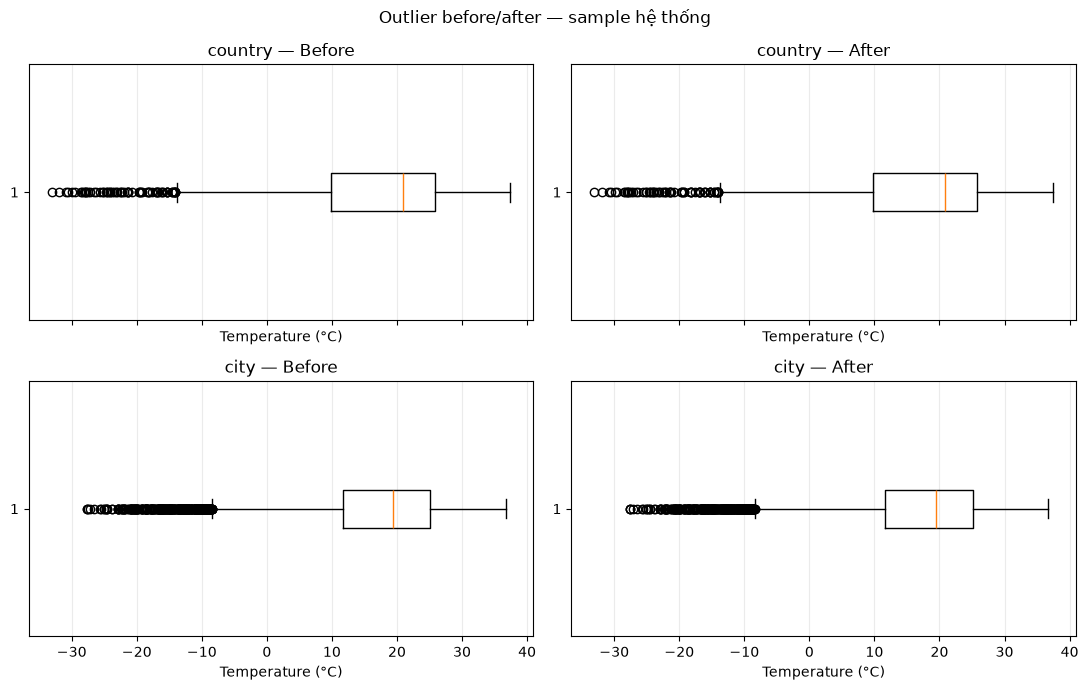

In [37]:
def temperature_sample(dataset_name: str, table: str, limit: int = 20_000) -> pd.DataFrame:
    """Lấy sample có hệ thống, tái lập được để trực quan outlier."""
    config = DATASETS[dataset_name]
    return read_sql(
        f'''
        SELECT {config["core_temperature"]} AS temperature
        FROM public.{table}
        WHERE {config["core_temperature"]} IS NOT NULL
          AND MOD({config["id_column"]}, 97) = 0
        ORDER BY {config["id_column"]}
        LIMIT {int(limit)};
        '''
    )


plot_datasets = ('country', 'city')
fig, axes = plt.subplots(len(plot_datasets), 2, figsize=(11, 7), sharex=True)

for row_index, dataset_name in enumerate(plot_datasets):
    config = DATASETS[dataset_name]
    before_sample = temperature_sample(dataset_name, config['source_table'])
    after_sample = temperature_sample(dataset_name, config['clean_table'])

    axes[row_index, 0].boxplot(
        before_sample['temperature'].dropna(), vert=False
    )
    axes[row_index, 0].set_title(f'{dataset_name} — Before')
    axes[row_index, 1].boxplot(
        after_sample['temperature'].dropna(), vert=False
    )
    axes[row_index, 1].set_title(f'{dataset_name} — After')

for axis in axes.ravel():
    axis.set_xlabel('Temperature (°C)')
    axis.grid(axis='x', alpha=0.25)

plt.suptitle('Outlier before/after — sample hệ thống')
plt.tight_layout()
plt.show()

### Nhận xét outlier

Số outlier IQR/Z-score sau cleaning có thể giảm nhẹ chỉ vì các dòng thiếu target đã bị loại, không phải vì notebook cắt bỏ cực trị. Các whisker và điểm ngoài boxplot vẫn xuất hiện ở cả hai phía; đây là kết quả mong đợi vì nhiệt độ cực đoan vẫn có ý nghĩa khí hậu khi nằm trong miền vật lý.

## 8. Kiểm tra khóa và quan hệ sau cleaning

Các bảng sạch giữ nguyên ID từ fact/view nguồn. Cell dưới xác nhận mọi `date_id`, `country_id`, `state_id`, `city_id` còn tham chiếu được đến dimension tương ứng; cleaning không tạo orphan key hoặc làm hỏng quan hệ.

In [38]:
RELATIONSHIP_AUDIT_SQL = '''
SELECT
    'clean_global_temperature' AS clean_table,
    COUNT(*) FILTER (WHERE d.date_id IS NULL)::BIGINT AS orphan_date,
    0::BIGINT AS orphan_location
FROM public.clean_global_temperature AS c
LEFT JOIN public.dim_date AS d ON d.date_id = c.date_id

UNION ALL

SELECT
    'clean_country_temperature',
    COUNT(*) FILTER (WHERE d.date_id IS NULL),
    COUNT(*) FILTER (WHERE co.country_id IS NULL)
FROM public.clean_country_temperature AS c
LEFT JOIN public.dim_date AS d ON d.date_id = c.date_id
LEFT JOIN public.dim_country AS co ON co.country_id = c.country_id

UNION ALL

SELECT
    'clean_state_temperature',
    COUNT(*) FILTER (WHERE d.date_id IS NULL),
    COUNT(*) FILTER (WHERE s.state_id IS NULL)
FROM public.clean_state_temperature AS c
LEFT JOIN public.dim_date AS d ON d.date_id = c.date_id
LEFT JOIN public.dim_state AS s ON s.state_id = c.state_id

UNION ALL

SELECT
    'clean_city_temperature',
    COUNT(*) FILTER (WHERE d.date_id IS NULL),
    COUNT(*) FILTER (WHERE ci.city_id IS NULL)
FROM public.clean_city_temperature AS c
LEFT JOIN public.dim_date AS d ON d.date_id = c.date_id
LEFT JOIN public.dim_city AS ci ON ci.city_id = c.city_id

UNION ALL

SELECT
    'clean_major_city_temperature',
    COUNT(*) FILTER (WHERE d.date_id IS NULL),
    COUNT(*) FILTER (WHERE ci.city_id IS NULL)
FROM public.clean_major_city_temperature AS c
LEFT JOIN public.dim_date AS d ON d.date_id = c.date_id
LEFT JOIN public.dim_city AS ci ON ci.city_id = c.city_id

ORDER BY clean_table;
'''

RELATIONSHIP_AUDIT_DF = read_sql(RELATIONSHIP_AUDIT_SQL)
RELATIONSHIP_AUDIT_DF['status'] = np.where(
    RELATIONSHIP_AUDIT_DF[['orphan_date', 'orphan_location']].sum(axis=1).eq(0),
    'PASS',
    'FAIL',
)
display(RELATIONSHIP_AUDIT_DF)

if RELATIONSHIP_AUDIT_DF['status'].ne('PASS').any():
    raise RuntimeError('Cleaning đã tạo orphan key; không thể bàn giao dữ liệu.')
print('RELATIONSHIP AUDIT: PASS')

,clean_table,orphan_date,orphan_location,status
0,clean_city_temperature,0,0,PASS
1,clean_country_temperature,0,0,PASS
2,clean_global_temperature,0,0,PASS
3,clean_major_city_temperature,0,0,PASS
4,clean_state_temperature,0,0,PASS


RELATIONSHIP AUDIT: PASS


## 9. Lưu dữ liệu sạch

Năm bảng `clean_*_temperature` đã là nguồn PostgreSQL chính thức cho notebook 04 trở đi. Để đáp ứng quy ước `data/processed/`, cell dưới cũng xuất 5 CSV theo schema phân tích gọn. File được ghi vào tệp tạm trước rồi mới thay thế, tránh để lại file dở nếu export lỗi.

In [39]:
EXPORT_QUERIES = {
    'global': '''
        SELECT
            observation_date AS dt,
            land_average_temperature,
            land_average_temperature_uncertainty,
            land_max_temperature,
            land_max_temperature_uncertainty,
            land_min_temperature,
            land_min_temperature_uncertainty,
            land_and_ocean_average_temperature,
            land_and_ocean_average_temperature_uncertainty
        FROM public.clean_global_temperature
        ORDER BY observation_date
    ''',
    'country': '''
        SELECT
            observation_date AS dt,
            average_temperature,
            average_temperature_uncertainty,
            country_name AS country
        FROM public.clean_country_temperature
        ORDER BY country_name, observation_date
    ''',
    'state': '''
        SELECT
            observation_date AS dt,
            average_temperature,
            average_temperature_uncertainty,
            state_name AS state,
            country_name AS country
        FROM public.clean_state_temperature
        ORDER BY country_name, state_name, observation_date
    ''',
    'city': '''
        SELECT
            observation_date AS dt,
            average_temperature,
            average_temperature_uncertainty,
            city_name AS city,
            country_name AS country,
            latitude,
            longitude
        FROM public.clean_city_temperature
        ORDER BY country_name, city_name, latitude, longitude, observation_date
    ''',
    'major_city': '''
        SELECT
            observation_date AS dt,
            average_temperature,
            average_temperature_uncertainty,
            city_name AS city,
            country_name AS country,
            latitude,
            longitude
        FROM public.clean_major_city_temperature
        ORDER BY country_name, city_name, latitude, longitude, observation_date
    ''',
}


def export_query_to_csv(query: str, destination: Path) -> None:
    """COPY query ra CSV qua file tạm rồi thay thế nguyên tử."""
    temporary_path = destination.with_suffix(destination.suffix + '.tmp')
    copy_sql = f'COPY ({query}) TO STDOUT WITH (FORMAT CSV, HEADER TRUE)'
    try:
        with closing(psycopg2.connect(**DB_CONFIG)) as connection:
            with connection.cursor() as cursor:
                with temporary_path.open('w', encoding='utf-8', newline='') as output:
                    cursor.copy_expert(copy_sql, output)
        temporary_path.replace(destination)
    finally:
        if temporary_path.exists():
            temporary_path.unlink()


export_rows = []
for dataset_name, query in EXPORT_QUERIES.items():
    output_path = PROCESSED_DIR / f'cleaned_{dataset_name}.csv'
    print(f'Đang export {output_path.name} ...')
    export_query_to_csv(query, output_path)
    export_rows.append({
        'dataset': dataset_name,
        'file': output_path.name,
        'size_mb': output_path.stat().st_size / (1024 ** 2),
    })

CSV_EXPORT_DF = pd.DataFrame(export_rows)
display(CSV_EXPORT_DF)

Đang export cleaned_global.csv ...
Đang export cleaned_country.csv ...
Đang export cleaned_state.csv ...
Đang export cleaned_city.csv ...
Đang export cleaned_major_city.csv ...


,dataset,file,size_mb
0,global,cleaned_global.csv,0.1931
1,country,cleaned_country.csv,20.3359
2,state,cleaned_state.csv,27.9345
3,city,cleaned_city.csv,283.7296
4,major_city,cleaned_major_city.csv,12.3750


## 10. Final audit và bàn giao cho Notebook 04

Final audit là bước chặn cuối: row count phải khớp data contract mới, missing cốt lõi/duplicate/invalid/logic errors phải bằng 0, quan hệ dimension phải còn nguyên và CSV export phải tồn tại. Chỉ khi toàn bộ điều kiện đạt, notebook mới công bố dữ liệu sẵn sàng.

In [40]:
FINAL_AUDIT_DF = AFTER_PROFILE_DF[
    [
        'dataset', 'table', 'rows', 'columns', 'core_missing_rows',
        'duplicate_rows', 'invalid_rows', 'logic_invalid_rows',
    ]
].copy()
FINAL_AUDIT_DF['expected_rows'] = FINAL_AUDIT_DF['dataset'].map(
    {
        name: config['expected_clean_rows']
        for name, config in DATASETS.items()
    }
)
FINAL_AUDIT_DF['row_count_ok'] = FINAL_AUDIT_DF['rows'].eq(
    FINAL_AUDIT_DF['expected_rows']
)
FINAL_AUDIT_DF['quality_ok'] = FINAL_AUDIT_DF[
    ['core_missing_rows', 'duplicate_rows', 'invalid_rows', 'logic_invalid_rows']
].sum(axis=1).eq(0)
FINAL_AUDIT_DF['status'] = np.where(
    FINAL_AUDIT_DF['row_count_ok'] & FINAL_AUDIT_DF['quality_ok'],
    'PASS',
    'FAIL',
)

display(FINAL_AUDIT_DF)

audit_output = PROCESSED_DIR / 'cleaning_audit.csv'
BEFORE_AFTER_DF.to_csv(audit_output, index=False)

failed = FINAL_AUDIT_DF.loc[
    FINAL_AUDIT_DF['status'].ne('PASS'), 'dataset'
].tolist()
if failed:
    raise RuntimeError('Final audit chưa đạt ở: ' + ', '.join(failed))
if RELATIONSHIP_AUDIT_DF['status'].ne('PASS').any():
    raise RuntimeError('Final audit quan hệ khóa chưa đạt.')
if not all(
    (PROCESSED_DIR / f'cleaned_{name}.csv').is_file()
    for name in DATASETS
):
    raise RuntimeError('Thiếu CSV export trong data/processed/.')

print('Tổng dòng trước cleaning:', f'{BEFORE_PROFILE_DF["rows"].sum():,}')
print('Tổng dòng sau cleaning  :', f'{AFTER_PROFILE_DF["rows"].sum():,}')
print('Audit report             :', audit_output)
print('DATA CLEANING PIPELINE: READY FOR NOTEBOOK 04')

,dataset,table,rows,columns,core_missing_rows,duplicate_rows,invalid_rows,logic_invalid_rows,expected_rows,row_count_ok,quality_ok,status
0,global,clean_global_temperature,3180,16,0,0,0,0,3180,True,True,PASS
1,country,clean_country_temperature,544811,12,0,0,0,0,544811,True,True,PASS
2,state,clean_state_temperature,620027,14,0,0,0,0,620027,True,True,PASS
3,city,clean_city_temperature,4967012,17,0,0,0,0,4967012,True,True,PASS
4,major_city,clean_major_city_temperature,228175,17,0,0,0,0,228175,True,True,PASS


Tổng dòng trước cleaning: 6,475,619
Tổng dòng sau cleaning  : 6,363,205
Audit report             : E:\FPT\HocKy3\PROJECT_1\PROJECT\Global-Surface-Temperature-Analysis\data\processed\cleaning_audit.csv
DATA CLEANING PIPELINE: READY FOR NOTEBOOK 04


## 11. Kết luận

Notebook đã trả lời bốn câu hỏi cốt lõi của Data Cleaning:

1. **Dữ liệu gặp vấn đề gì?** Missing tập trung ở nhiệt độ và uncertainty; không có duplicate, invalid coordinate, invalid physical temperature hay lỗi grain theo tháng.
2. **Đã xử lý thế nào và vì sao?** Loại dòng thiếu nhiệt độ cốt lõi, điền uncertainty theo median entity, giữ outlier thống kê hợp lệ và duy trì các giá trị Global missing có hệ thống.
3. **Chất lượng thay đổi ra sao?** Bảng before/after ghi rõ số dòng, missing, duplicate, invalid, outlier và payload cho từng dataset. Kết quả đúng theo data contract mới là:
   - Global: 3.192 → 3.180
   - Country: 577.462 → 544.811
   - State: 645.675 → 620.027
   - City: 5.010.113 → 4.967.012
   - Major City: 239.177 → 228.175
   - Tổng: 6.475.619 → 6.363.205
4. **Dữ liệu đã sẵn sàng chưa?** Khi Final audit in `DATA CLEANING PIPELINE: READY FOR NOTEBOOK 04`, 5 bảng `clean_*_temperature` là nguồn duy nhất nên dùng cho EDA và Feature Engineering; các notebook sau không đọc lại CSV raw.

## 12. Checklist hoàn thành Notebook 03

- [x] Giới thiệu mục tiêu, vai trò và pipeline cleaning.
- [x] Đọc dữ liệu từ PostgreSQL bằng `pd.read_sql_query()`; không đọc CSV raw.
- [x] Kiểm tra shape, SQL data type và payload.
- [x] Thống kê và trực quan missing.
- [x] Kiểm tra duplicate theo business grain.
- [x] Kiểm tra invalid values và logic nghiệp vụ.
- [x] Phát hiện outlier bằng IQR và Z-score; giải thích quyết định giữ.
- [x] Chuẩn hóa ngày, text/category và kiểu dữ liệu khi đọc vào pandas.
- [x] Cleaning riêng cho cả 5 dataset.
- [x] So sánh before/after.
- [x] Kiểm tra khóa và quan hệ sau cleaning.
- [x] Lưu dữ liệu sạch vào PostgreSQL.
- [x] Xuất dữ liệu tái tạo được vào `data/processed/`.
- [x] Final audit và bàn giao rõ ràng cho notebook 04.